In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib as mpl

In [2]:
df1 = pd.read_csv("/home/users/nhorst/project/clembench2/clembench/evaluated_runs/H100/llama_8B/raw.csv", index_col = 0)
df2 = pd.read_csv("/home/users/nhorst/project/clembench2/clembench/evaluated_runs/H100/llama_70B/raw.csv", index_col = 0)
df3 = pd.read_csv("/home/users/nhorst/project/clembench2/clembench/evaluated_runs/H100/mistral/raw.csv", index_col = 0)

df = pd.concat([df1, df2, df3])

df = df[~(df.model == "Mistral-small-2409-DFINAL_1.7K-steps-t0.0--Mistral-small-2409-DFINAL_1.7K-steps-t0.0")]

df = df[~df.metric.isin(["experiment variable", "experiment name"])] # string based metrics we don't need
df.value = pd.to_numeric(df.value)

In [10]:
df.model.value_counts()

model
Mistral-small-2501-DFINAL_0.6K-steps-t0.0--Mistral-small-2501-DFINAL_0.6K-steps-t0.0          16435
Unsloth-meta-llama-3.1-70B-bnb-4bit-t0.0--Unsloth-meta-llama-3.1-70B-bnb-4bit-t0.0            16420
llama3.1-70B-sft-e1-DFINAL_0.6K-steps-t0.0--llama3.1-70B-sft-e1-DFINAL_0.6K-steps-t0.0        16418
llama3.1-8B-sft-e1-DFINAL-t0.0--llama3.1-8B-sft-e1-DFINAL-t0.0                                16407
Unsloth-meta-llama-3.1-4bit-plain-t0.0--Unsloth-meta-llama-3.1-4bit-plain-t0.0                16405
llama3.1-8B-sft-e1-DFINAL_0.7K-steps-t0.0--llama3.1-8B-sft-e1-DFINAL_0.7K-steps-t0.0          16403
llama3.1-8B-sft-e1-DFINAL_1.7K-steps-t0.0--llama3.1-8B-sft-e1-DFINAL_1.7K-steps-t0.0          16401
llama3.1-70B-sft-e1-DFINAL_1.1K-steps-t0.0--llama3.1-70B-sft-e1-DFINAL_1.1K-steps-t0.0        16394
llama3.1-70B-sft-e1-DFINAL_1.7K-steps-t0.0--llama3.1-70B-sft-e1-DFINAL_1.7K-steps-t0.0        16377
Unsloth-Mistral-Small-24B-Instruct-2501-t0.0--Unsloth-Mistral-Small-24B-Instruct-2501-t0.0    

In [3]:
old_games = ["imagegame", "privateshared", "referencegame", "taboo", "wordle", "wordle_withclue", "wordle_withcritic"]
new_games = ["adventuregame", "codenames", "guesswhat", "matchit_ascii", "textmapworld", "textmapworld_graphreasoning", "textmapworld_specificroom"]

names = {
    "llama3.1-8B-sft-e1-DFINAL-t0.0--llama3.1-8B-sft-e1-DFINAL-t0.0": "8B_DFIN", 
    "Unsloth-meta-llama-3.1-4bit-plain-t0.0--Unsloth-meta-llama-3.1-4bit-plain-t0.0": "8B_base", 
    "llama3.1-8B-sft-e1-DFINAL_0.7K-steps-t0.0--llama3.1-8B-sft-e1-DFINAL_0.7K-steps-t0.0": "8B_0.7",
    "llama3.1-8B-sft-e1-DFINAL_1.7K-steps-t0.0--llama3.1-8B-sft-e1-DFINAL_1.7K-steps-t0.0": "8B_1.7", 
    "llama3.1-8B-sft-e1-DFINAL_1.1K-steps-t0.0--llama3.1-8B-sft-e1-DFINAL_1.1K-steps-t0.0": "8B_1.1",
    "llama3.1-sft-e1-_E1_D40005-t0.0--llama3.1-sft-e1-_E1_D40005-t0.0": "8B_D4",
    "Unsloth-meta-llama-3.1-70B-bnb-4bit-t0.0--Unsloth-meta-llama-3.1-70B-bnb-4bit-t0.0": "70B_base",
    "llama3.1-70B-sft-e1-DFINAL_0.6K-steps-t0.0--llama3.1-70B-sft-e1-DFINAL_0.6K-steps-t0.0": "70B_0.6",
    "llama3.1-70B-sft-e1-DFINAL_1.1K-steps-t0.0--llama3.1-70B-sft-e1-DFINAL_1.1K-steps-t0.0": "70B_1.1",
    "llama3.1-70B-sft-e1-DFINAL_1.7K-steps-t0.0--llama3.1-70B-sft-e1-DFINAL_1.7K-steps-t0.0": "70B_1.7",
    "Unsloth-Mistral-Small-24B-Instruct-2501-t0.0--Unsloth-Mistral-Small-24B-Instruct-2501-t0.0": "24B_base",
    "Mistral-small-2409-DFINAL_1.7K-steps-t0.0--Mistral-small-2409-DFINAL_1.7K-steps-t0.0": "22B_1.7",
    "Mistral-small-2501-DFINAL_1.7K-steps-t0.0--Mistral-small-2501-DFINAL_1.7K-steps-t0.0": "24B_1.7", 
    "Mistral-small-2501-DFINAL_1.1K-steps-t0.0--Mistral-small-2501-DFINAL_1.1K-steps-t0.0": "24B_1.1",
    "Mistral-small-2501-DFINAL_0.6K-steps-t0.0--Mistral-small-2501-DFINAL_0.6K-steps-t0.0": "24B_0.6"
 }

In [ ]:
df[df.game == "codenames"].metric.value_counts()
# Parsed Request Count
# Number of turns
# Aborted 
# Average Cluegiver Number of Targets

In [ ]:
df[df.metric == "entity_not_accessible"].value.value_counts()
# successful_actions
# turn_limit_loss 
# turn_ratio
# achieved_goal_ratio
# action_parsing_fail

In [ ]:
game = "imagegame"
baseline = "baseline_8B"
game_df = df[df.game == game].replace(names)

n_cols = 3
n_rows = math.ceil(len(game_df.metric.unique()) / n_cols)

plt.figure(figsize=(15, 12))
plt.subplots_adjust(hspace=0.5)
plt.suptitle(game.title() + " metrics overview", fontsize=18, y=0.95)

for n, metric in  enumerate(game_df.metric.unique()):
    mdf = game_df[game_df.metric == metric]
    i = mdf[["model", "value"]].groupby(by = "model").mean()
    stds = mdf[["model", "value"]].groupby(by = "model").std()
    baseline_idx = list(i.index).index(baseline)

    ax = plt.subplot(n_rows, n_cols, n+1)
    barplot = plt.bar(i.index, i.value, yerr = stds.value)
    barplot[baseline_idx].set_color('indianred')


    ax.set_title(metric)
    #plt.tick_params('x', labelbottom=False)
    #plt.title(metric)
plt.show()


In [15]:
df70 = pd.read_csv("/home/users/nhorst/project/clembench2/clembench/results/raw.csv", index_col = 0)
df70 = df70[~df70.metric.isin(["experiment variable", "experiment name"])] # string based metrics we don't need
df70.value = pd.to_numeric(df70.value)
df70.model.value_counts()
baseline = "baseline_70B"

In [ ]:
game = "imagegame"
game_df = df70[df70.game == game].replace(names)

n_cols = 3
n_rows = math.ceil(len(game_df.metric.unique()) / n_cols)

plt.figure(figsize=(15, 12))
plt.subplots_adjust(hspace=0.5)
plt.suptitle(game.title() + " metrics overview", fontsize=18, y=0.95)

for n, metric in  enumerate(game_df.metric.unique()):
    mdf = game_df[game_df.metric == metric]
    i = mdf[["model", "value"]].groupby(by = "model").mean()
    stds = mdf[["model", "value"]].groupby(by = "model").std()
    baseline_idx = list(i.index).index(baseline)

    ax = plt.subplot(n_rows, n_cols, n+1)
    barplot = plt.bar(i.index, i.value, yerr = stds.value)
    barplot[baseline_idx].set_color('gold')


    ax.set_title(metric)
    #plt.tick_params('x', labelbottom=False)
    #plt.title(metric)
plt.show()


In [ ]:
big_df = pd.concat([df, df70])


model
Unsloth-meta-llama-3.1-70B-bnb-4bit-t0.0--Unsloth-meta-llama-3.1-70B-bnb-4bit-t0.0        16420
llama3.1-8B-sft-e1-DFINAL-t0.0--llama3.1-8B-sft-e1-DFINAL-t0.0                            16407
Unsloth-meta-llama-3.1-4bit-plain-t0.0--Unsloth-meta-llama-3.1-4bit-plain-t0.0            16405
llama3.1-8B-sft-e1-DFINAL_1.7K-steps-t0.0--llama3.1-8B-sft-e1-DFINAL_1.7K-steps-t0.0      16401
llama3.1-70B-sft-e1-DFINAL_1.7K-steps-t0.0--llama3.1-70B-sft-e1-DFINAL_1.7K-steps-t0.0    16377
llama3.1-8B-sft-e1-DFINAL_1.1K-steps-t0.0--llama3.1-8B-sft-e1-DFINAL_1.1K-steps-t0.0      16256
llama3.1-sft-e1-_E1_D40005-t0.0--llama3.1-sft-e1-_E1_D40005-t0.0                          15765
Name: count, dtype: int64

## All metrics for all games

In [4]:
model_shorts = ["8B_base", "8B_DFIN", "8B_0.7", "8B_1.1", "8B_1.7", "8B_D4", "24B_base", "24B_0.6", "24B_1.1", "24B_1.7", "70B_base", "70B_0.6", "70B_1.1", "70B_1.7"]

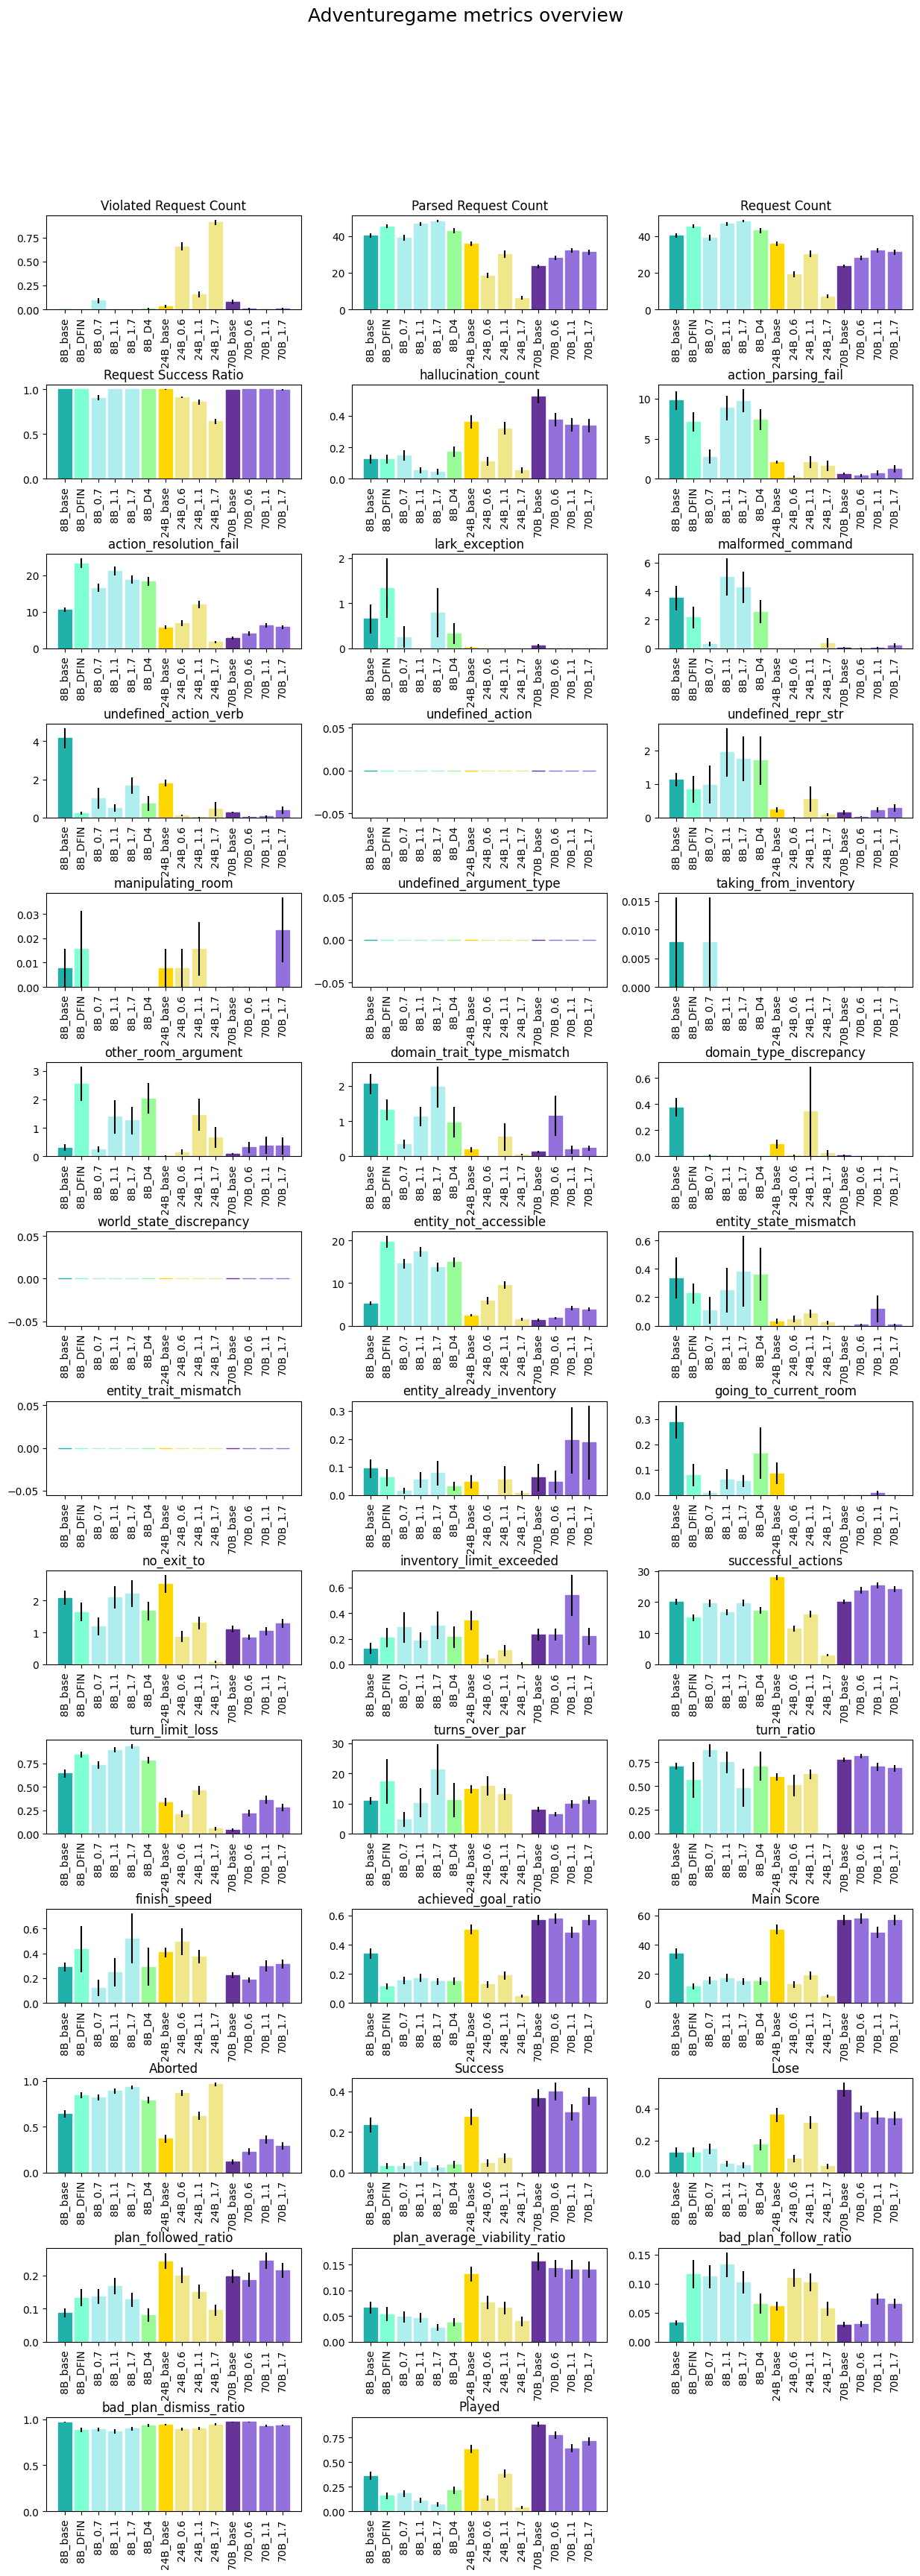

In [53]:
game = "matchit_ascii"
games = ["adventuregame", "codenames", "referencegame", "imagegame", "textmapworld", "guesswhat", "privateshared", "taboo", "textmapworld_specificroom", "textmapworld_graphreasoning", "wordle_withcritic", "matchit_ascii", "wordle", "wordle_withclue"]
games = ["adventuregame"]
for game in games:
    game_df = df[df.game == game].replace(names)

    n_cols = 3
    n_rows = math.ceil(len(game_df.metric.unique()) / n_cols)

    plt.figure(figsize=(15, 40))
    plt.subplots_adjust(hspace=0.8)
    plt.suptitle(game.title() + " metrics overview", fontsize=18, y=0.95)

    for n, metric in  enumerate(game_df.metric.unique()):
        mdf = game_df[game_df.metric == metric]
        i = mdf[["model", "value"]].groupby(by = "model").mean().reindex(model_shorts)
        stds = mdf[["model", "value"]].groupby(by = "model").sem().reindex(model_shorts)

        ax = plt.subplot(n_rows, n_cols, n+1)
        barplot = plt.bar(i.index, i.value, yerr = stds.value)

        id_baseline8 = list(i.index).index("8B_base")
        idb70 = list(i.index).index("70B_base")
        id_dfin = list(i.index).index("8B_DFIN")
        id811 = list(i.index).index('8B_1.1')
        id807 = list(i.index).index('8B_0.7')
        id817 = list(i.index).index("8B_1.7")
        id_d4 = list(i.index).index("8B_D4")
        id24b = list(i.index).index('24B_base')
        id2417 =  list(i.index).index('24B_1.7')
        id2411 = list(i.index).index('24B_1.1')
        id2406 =  list(i.index).index('24B_0.6')
        id7011 = list(i.index).index('70B_1.1')
        id7006 = list(i.index).index('70B_0.6')
        id7017 = list(i.index).index("70B_1.7")
        barplot[id_baseline8].set_color('lightseagreen')
        barplot[id_dfin].set_color('aquamarine')
        barplot[id817].set_color('paleturquoise')
        barplot[id807].set_color('paleturquoise')
        barplot[id811].set_color('paleturquoise')
        barplot[id_d4].set_color('palegreen')
        barplot[idb70].set_color('rebeccapurple')
        barplot[id7017].set_color('mediumpurple')
        barplot[id7011].set_color('mediumpurple')
        barplot[id7006].set_color('mediumpurple')
        barplot[id24b].set_color('gold')
        barplot[id2417].set_color('khaki')
        barplot[id2411].set_color('khaki')
        barplot[id2406].set_color('khaki')

        ax.set_title(metric)
        plt.tick_params('x', rotation = 90)#labelbottom=False)
        #plt.title(metric)
    plt.savefig("plots/overview_metrics_" + game + ".pdf", bbox_inches = "tight")
    plt.show()

## Main score and played for all games together

In [5]:
df1 = pd.read_csv("/home/users/nhorst/project/clembench2/clembench/evaluated_runs/H100/llama_8B/raw.csv", index_col = 0)
df2 = pd.read_csv("/home/users/nhorst/project/clembench2/clembench/evaluated_runs/H100/llama_70B/raw.csv", index_col = 0)
df3 = pd.read_csv("/home/users/nhorst/project/clembench2/clembench/evaluated_runs/H100/mistral/raw.csv", index_col = 0)

df = pd.concat([df1, df2, df3])
df = df[~df.metric.isin(["experiment variable", "experiment name"])] # string based metrics we don't need
df.value = pd.to_numeric(df.value)
df.model.value_counts()

model
Mistral-small-2501-DFINAL_0.6K-steps-t0.0--Mistral-small-2501-DFINAL_0.6K-steps-t0.0          16435
Unsloth-meta-llama-3.1-70B-bnb-4bit-t0.0--Unsloth-meta-llama-3.1-70B-bnb-4bit-t0.0            16420
llama3.1-70B-sft-e1-DFINAL_0.6K-steps-t0.0--llama3.1-70B-sft-e1-DFINAL_0.6K-steps-t0.0        16418
llama3.1-8B-sft-e1-DFINAL-t0.0--llama3.1-8B-sft-e1-DFINAL-t0.0                                16407
Unsloth-meta-llama-3.1-4bit-plain-t0.0--Unsloth-meta-llama-3.1-4bit-plain-t0.0                16405
llama3.1-8B-sft-e1-DFINAL_0.7K-steps-t0.0--llama3.1-8B-sft-e1-DFINAL_0.7K-steps-t0.0          16403
llama3.1-8B-sft-e1-DFINAL_1.7K-steps-t0.0--llama3.1-8B-sft-e1-DFINAL_1.7K-steps-t0.0          16401
llama3.1-70B-sft-e1-DFINAL_1.1K-steps-t0.0--llama3.1-70B-sft-e1-DFINAL_1.1K-steps-t0.0        16394
llama3.1-70B-sft-e1-DFINAL_1.7K-steps-t0.0--llama3.1-70B-sft-e1-DFINAL_1.7K-steps-t0.0        16377
Unsloth-Mistral-Small-24B-Instruct-2501-t0.0--Unsloth-Mistral-Small-24B-Instruct-2501-t0.0    

In [10]:
model_shorts = ["8B_base", "8B_0.7", "8B_1.1", "8B_1.7", "8B_DFIN", "24B_base", "24B_0.6", "24B_1.1", "24B_1.7", "70B_base", "70B_0.6", "70B_1.1", "70B_1.7"]
colorp = {
    "8B_base": '#e78c4b', 
    "8B_DFIN": '#F7D9C4', 
    "8B_0.7": '#F7D9C4',
    "8B_1.1": '#F7D9C4', 
    "8B_1.7": '#F7D9C4', 
    "24B_base": '#5b9fd7',
    "24B_0.6": '#C6DEF1',
    "24B_1.1": '#C6DEF1', 
    "24B_1.7": '#C6DEF1', 
    "70B_base": '#9684ae',
    "70B_0.6": '#d8d1e1',
    "70B_1.1": '#d8d1e1', 
    "70B_1.7": '#d8d1e1'
}

/tmp/ipykernel_2762681/2015900451.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(n_qual.index, rotation = 35, ha="right")
/tmp/ipykernel_2762681/2015900451.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(n_qual.index, rotation = 35, ha="right")
/tmp/ipykernel_2762681/2015900451.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(n_qual.index, rotation = 35, ha="right")
/tmp/ipykernel_2762681/2015900451.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(n_qual.index, rotation = 35, ha="right")
/tmp/ipykernel_2762681/2015900451.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(n_qual.index, rotation = 35, ha="right")
/tmp/ipykernel_2762681/2015900451.py:57: UserWarning: FixedFormatter should only be used together with FixedLo

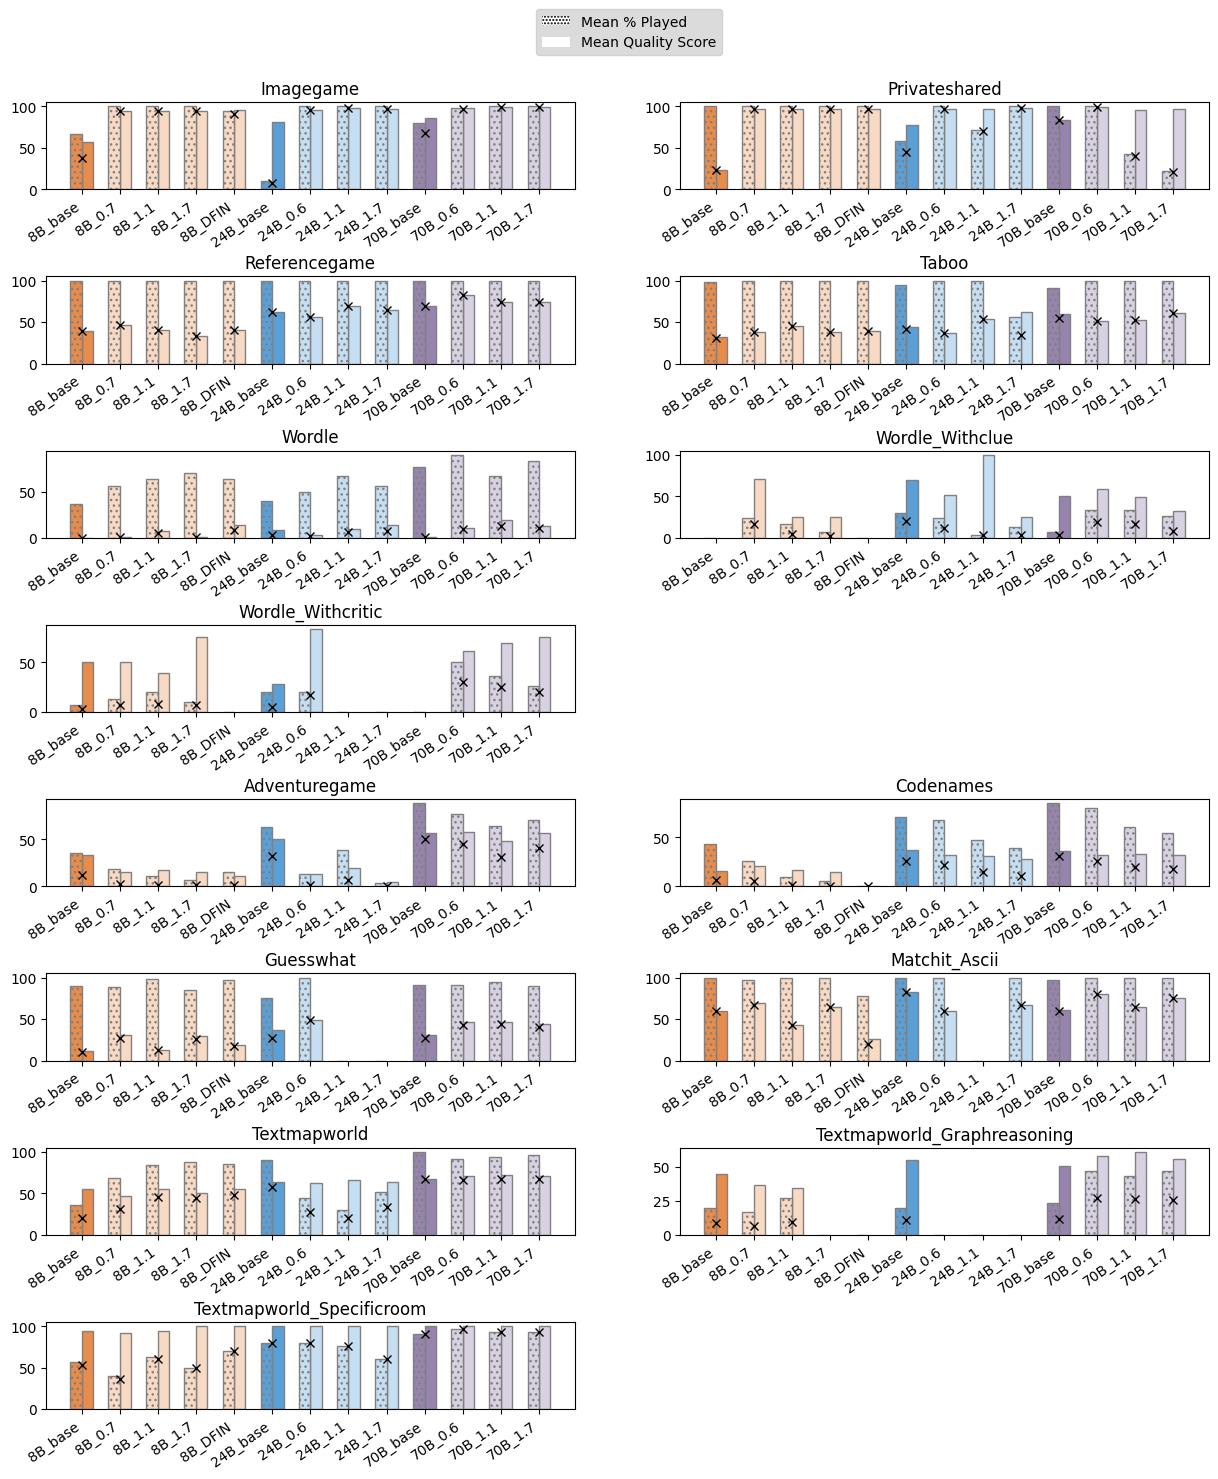

In [ ]:
# plot everything
#mpl.rcParams['hatch.linewidth'] = 1 # previous pdf hatch linewidth

games = old_games + ["empty game"] + new_games

n_cols = 2
n_rows = math.ceil(len(df.metric.unique()) / n_cols)

plt.figure(figsize=(15,100))
plt.subplots_adjust(hspace=1, top=0.99)#, left = -0.1)
circ1 = mpatches.Patch( facecolor="white",hatch=".....",label='Mean % Played') #alpha=a_val
circ2= mpatches.Patch( facecolor="white",hatch='',label='Mean Quality Score') # alpha=a_val
plt.figlegend(handles = [circ1,circ2], 
              bbox_to_anchor = (0.58, 1),
              facecolor = "lightgrey")
#plt.subplots_adjust()
#plt.suptitle("Played metrics overview", fontsize=18, y=0.95)
#plt.tight_layout()

for n, game in enumerate(games):
    
    if game == "empty game":
        ax = plt.subplot(n_rows, n_cols, n+1)
        plt.axis('off')
    else:

        game_df = df[df.game == game].replace(names)

        played_df = game_df[game_df.metric == "Played"]
        n_played = (played_df[["model", "value"]]
                    .groupby(by = "model")
                    .mean()
                    .reindex(model_shorts)*100)
        

        qual_df = game_df[game_df.metric == "Main Score"]
        n_qual = (qual_df[["model", "value"]]
                .groupby(by = "model")
                .mean()
                .reindex(model_shorts))



        ax = plt.subplot(n_rows, n_cols, n+1)
        barplot_q = plt.bar(n_qual.index, n_qual.value, 0.3, 
                            align = "edge", 
                            edgecolor = "grey",
                            color = list(colorp.values()))#, yerr = stds.value)
        barplot_p = plt.bar(n_played.index, n_played.value, -0.3, 
                            align = "edge", 
                            edgecolor = "grey", 
                            hatch = "...",
                            color = list(colorp.values()))
        
        plt.plot((n_played * n_qual)/100, "kx")
        ax.set_title(game.title())
        ax.set_xticklabels(n_qual.index, rotation = 35, ha="right")
plt.show()

### Plot only final models

In [17]:
df.model.value_counts()

model
Mistral-small-2501-DFINAL_0.6K-steps-t0.0--Mistral-small-2501-DFINAL_0.6K-steps-t0.0          16435
Unsloth-meta-llama-3.1-70B-bnb-4bit-t0.0--Unsloth-meta-llama-3.1-70B-bnb-4bit-t0.0            16420
Unsloth-meta-llama-3.1-4bit-plain-t0.0--Unsloth-meta-llama-3.1-4bit-plain-t0.0                16405
llama3.1-70B-sft-e1-DFINAL_1.7K-steps-t0.0--llama3.1-70B-sft-e1-DFINAL_1.7K-steps-t0.0        16377
Unsloth-Mistral-Small-24B-Instruct-2501-t0.0--Unsloth-Mistral-Small-24B-Instruct-2501-t0.0    16372
Name: count, dtype: int64

In [15]:
final_models = ["Unsloth-meta-llama-3.1-4bit-plain-t0.0--Unsloth-meta-llama-3.1-4bit-plain-t0.0", "llama3.1-8B-sft-e1-DFINAL_0.7K-steps-t0.0--llama3.1-8B-sft-e1-DFINAL_0.7K-steps-t0.0", 
    "Unsloth-meta-llama-3.1-70B-bnb-4bit-t0.0--Unsloth-meta-llama-3.1-70B-bnb-4bit-t0.0", "llama3.1-70B-sft-e1-DFINAL_1.7K-steps-t0.0--llama3.1-70B-sft-e1-DFINAL_1.7K-steps-t0.0", "Unsloth-Mistral-Small-24B-Instruct-2501-t0.0--Unsloth-Mistral-Small-24B-Instruct-2501-t0.0", "Mistral-small-2501-DFINAL_0.6K-steps-t0.0--Mistral-small-2501-DFINAL_0.6K-steps-t0.0"]
model_shorts = ["8B_base", "8B_0.7", "24B_base", "24B_0.6", "70B_base", "70B_0.6"]
colorp = {
    "8B_base": '#e78c4b', 
    "8B_0.7": '#F7D9C4', 
    "24B_base": '#5b9fd7',
    "24B_0.6": '#C6DEF1',
    "70B_base": '#9684ae', 
    "70B_0.6": '#d8d1e1'
}

/tmp/ipykernel_2728198/3288531450.py:68: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(n_qual.index, rotation = 35, ha="right")
/tmp/ipykernel_2728198/3288531450.py:68: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(n_qual.index, rotation = 35, ha="right")
/tmp/ipykernel_2728198/3288531450.py:68: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(n_qual.index, rotation = 35, ha="right")
/tmp/ipykernel_2728198/3288531450.py:68: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(n_qual.index, rotation = 35, ha="right")
/tmp/ipykernel_2728198/3288531450.py:68: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(n_qual.index, rotation = 35, ha="right")
/tmp/ipykernel_2728198/3288531450.py:68: UserWarning: FixedFormatter should only be used together with FixedLo

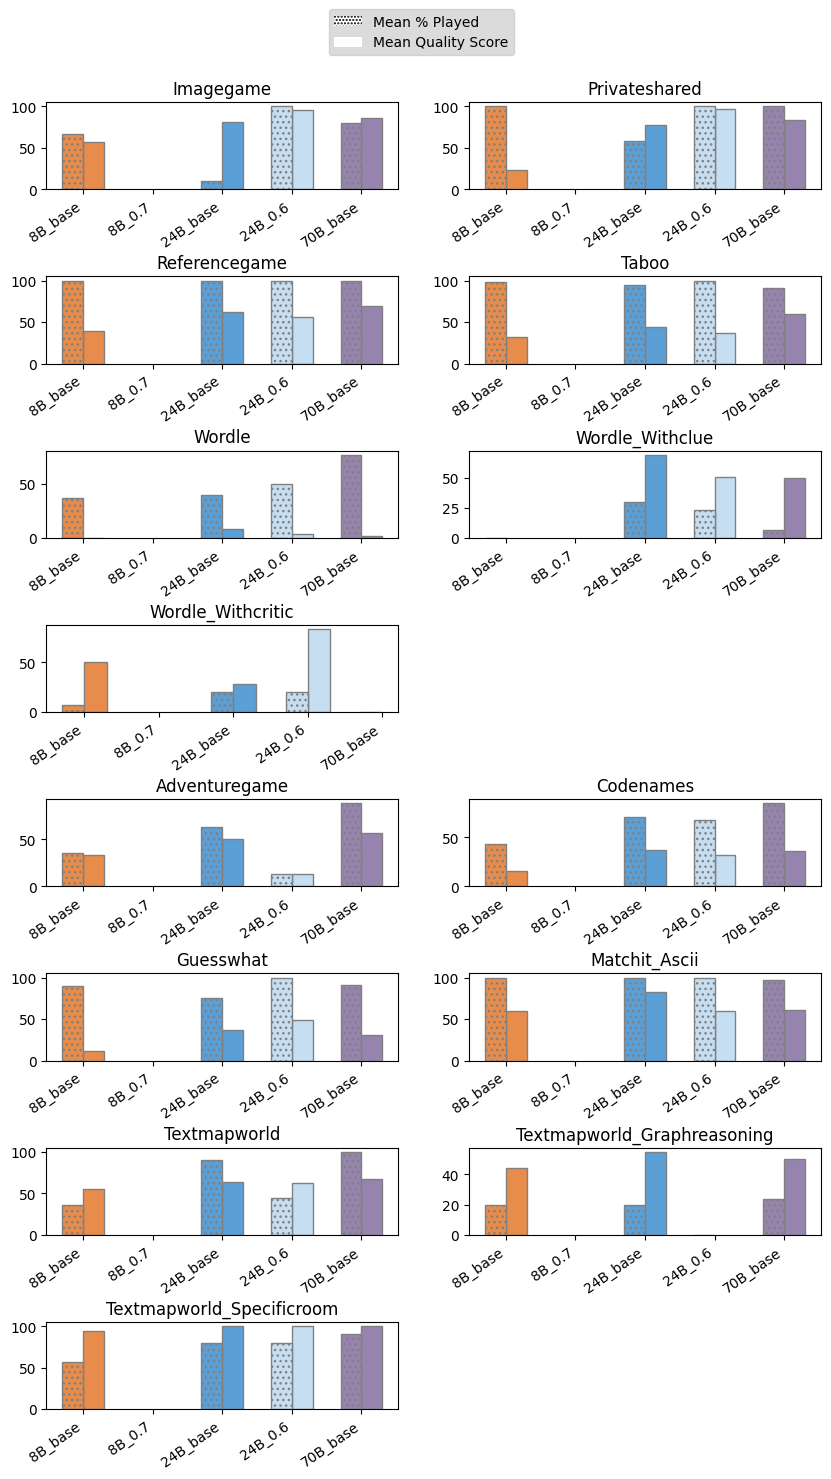

In [16]:
df = df[df.model.isin(final_models)]

#mpl.rcParams['hatch.linewidth'] = 1 # previous pdf hatch linewidth


games = old_games + ["empty_game"] + new_games

n_cols = 2
n_rows = math.ceil(len(df.metric.unique()) / n_cols)

plt.figure(figsize=(10,100 ))
plt.subplots_adjust(hspace=1, top=0.99)#, left = -0.1)
#plt.suptitle("Title", fontsize=18, x = 0.3)
circ1 = mpatches.Patch( facecolor="white",hatch=".....",label='Mean % Played') #alpha=a_val
circ2= mpatches.Patch( facecolor="white",hatch='',label='Mean Quality Score') # alpha=a_val
plt.figlegend(handles = [circ1,circ2], 
              bbox_to_anchor = (0.6, 1),
              facecolor = "lightgrey")
#plt.subplots_adjust()
#plt.suptitle("Played metrics overview", fontsize=18, y=0.95)
#plt.tight_layout()

for n, game in enumerate(games):
    if game == "empty_game":
        ax = plt.subplot(n_rows, n_cols, n+1)
        plt.axis('off')
    else:
        game_df = df[df.game == game].replace(names)

        played_df = game_df[game_df.metric == "Played"]
        n_played = (played_df[["model", "value"]]
                    .groupby(by = "model")
                    .mean()
                    .reindex(model_shorts)*100)
        

        qual_df = game_df[game_df.metric == "Main Score"]
        n_qual = (qual_df[["model", "value"]]
                .groupby(by = "model")
                .mean()
                .reindex(model_shorts))


        #merged = pd.merge(n_played*100, n_qual, on = "model")

        ax = plt.subplot(n_rows, n_cols, n+1)
        barplot_q = plt.bar(n_qual.index, n_qual.value, 0.3, 
                            align = "edge", 
                            edgecolor = "grey",
                            color = list(colorp.values()))#, yerr = stds.value)
        barplot_p = plt.bar(n_played.index, n_played.value, -0.3, 
                            align = "edge", 
                            edgecolor = "grey", 
                            hatch = "...",
                            color = list(colorp.values()))#, yerr = stds.value)

        # for model in model_shorts:
        #     idx_played = list(n_played.index).index(model)
        #     barplot_p[idx_played].set_color(colorp[model])
        #     idx_quality = list(n_qual.index).index(model)
        #     barplot_q[idx_quality].set_hatch("\\")
        #     #barplot_q[idx_quality].set_color(colorq[model])


        #barplot = merged.plot.bar()
        #qual_df[["model", "value"]].groupby(by = "model").mean().plot.bar()
        ax.set_title(game.title())
        ax.set_xticklabels(n_qual.index, rotation = 35, ha="right")
        #plt.tick_params('x', rotation = 35, ha="left")#labelbottom=False)
plt.show()